In [4]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install xgboost

  Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl (2.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 20.3 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 17.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
import xarray as xr
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Data import: Loading NetCDF file
file_path = "preprocessed_merged_dataset.nc"  # Change to your file path
dataset = xr.open_dataset(file_path)

# Define the latitude and longitude range of the target area (49.4~58.9 latitude, 352.5~358.75 longitude)
lat_min, lat_max = 49.4, 58.9
lon_min, lon_max = 352.5, 358.75  # Convert to 0~360 coordinate system

# Select the data of the target area from the original data set
lat_indices = (dataset.lat >= lat_min) & (dataset.lat <= lat_max)
lon_indices = (dataset.lon >= lon_min) & (dataset.lon <= lon_max)

# Extract data of target area: TREFHT and other features (such as TREFMXAV_U, FLNS, etc.)
selected_data = dataset[['TREFHT', 'TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']].isel(lat=lat_indices, lon=lon_indices)

# Convert xarray data to pandas DataFrame
df_sel = selected_data.to_dataframe().reset_index()

# Convert the time column to datetime type
df_sel['time'] = pd.to_datetime(df_sel['time'])

# Divide the training set and test set (use time segmentation: before January 1, 2025 is the training set, and after January 1, 2025 is the test set)
train_df = df_sel[df_sel['time'] < '2025-01-01']
test_df = df_sel[df_sel['time'] >= '2025-01-01']

print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Test samples: {len(test_df)}")

# Select features and target variables
features = ['TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']
target = 'TREFHT'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# Create and train an XGBoost model
best_xgb = XGBRegressor(
    subsample=0.6,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=1500,
    min_child_weight=10,
    max_depth=8,
    learning_rate=0.01,
    gamma=0.1,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42
)

best_xgb.fit(X_train, y_train)

# predict
y_pred_optimized = best_xgb.predict(X_test)

# Calculate the number of prediction samples
N = len(y_pred_optimized)
print(f"✅ Predicted samples: {N}")

# Calculate the total number of days from 2025-01-01 to 2080-12-12
start_date = pd.to_datetime("2025-01-01")
end_date = pd.to_datetime("2080-12-12")
total_days = (end_date - start_date).days + 1  # Including the start date

print(f"✅ Total days in the prediction range: {total_days}")

# Ensure that the number of prediction samples is consistent with the time range
N = min(len(y_pred_optimized), total_days)  # Prevent the number of samples from exceeding the time range

# Construct time series (2025-01-01 to 2080-12-12)
time = pd.date_range(start=start_date, periods=N, freq="D")

# Latitude and longitude
lat = np.linspace(lat_min, lat_max, len(df_sel['lat'].unique()))  # Generate latitude values based on the selected latitude range
lon = np.linspace(lon_min, lon_max, len(df_sel['lon'].unique()))  # Generate longitude values based on the selected longitude range

# Ensure that the length of the forecast results conforms to the time, latitude and longitude grid
pred_data = y_pred_optimized[:N]

# Calculate the number of latitude and longitude points at each time step
num_lat = len(lat)
num_lon = len(lon)

# Check if the forecast output meets the requirements
# Calculate the number of latitude × longitude points predicted for each time step
expected_samples_per_time_step = num_lat * num_lon

# If the number of predicted samples is 20435, and you expect N * num_lat * num_lon, what adjustments should be made to the calculation
# Assume that the prediction result at each time point should be the prediction data of latitude * longitude
N = len(y_pred_optimized) // expected_samples_per_time_step  # Ensure that the number of prediction samples is a reasonable number of time steps

print(f"✅ Predicted samples per time step: {expected_samples_per_time_step}")
print(f"✅ Number of time steps: {N}")

# Reshape the prediction result into (time, latitude, longitude)
pred_data_reshaped = y_pred_optimized.reshape((N, num_lat, num_lon))

# Construct Dataset
ds_fixed = xr.Dataset(
    {
        "predicted_value": (("time", "lat", "lon"), pred_data_reshaped)
    },
    coords={
        "time": time[:N],  # Make sure the time series matches the number of samples
        "lat": lat,
        "lon": lon
    }
)

# Save as NetCDF file
ds_fixed.to_netcdf("xgboost_predictions_fixed.nc")

print("✅ Repair completed, saved asxgboost_predictions_fixed.nc")


✅ Train samples: 416340
✅ Test samples: 1226100
✅ Predicted samples: 1226100
✅ Total days in the prediction range: 20435
✅ Predicted samples per time step: 60
✅ Number of time steps: 20435
✅ Repair completed, saved asxgboost_predictions_fixed.nc


# Cross Validation

In [24]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Create model
best_xgb = XGBRegressor(
    subsample=0.6,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=1500,
    min_child_weight=10,
    max_depth=8,
    learning_rate=0.01,
    gamma=0.1,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42
)

# Time series cross validation
tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(best_xgb, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
print("Cross-validated MAE (TimeSeriesSplit):", -scores)
print("Average MAE:", -scores.mean())


Cross-validated MAE (TimeSeriesSplit): [0.3660188  0.36579987 0.33610117 0.36050814 0.35844186]
Average MAE: 0.357373970746994


The overall error is between 0.336 and 0.366, with a small fluctuation range, indicating that the model performs stably under different time segments;

The average MAE is 0.357, which is a good estimate of the model's generalization ability in the time dimension;

The third fold performs best (0.3361), which may be a good fit between that period of data and the model;

No fold has a particularly high error, and the model does not have an obvious time period collapse problem.

# Prediction results for all latitude and longitude points in the entire area

✅ Optimized MAE: 0.42 °C
✅ Optimized RMSE: 0.56 °C


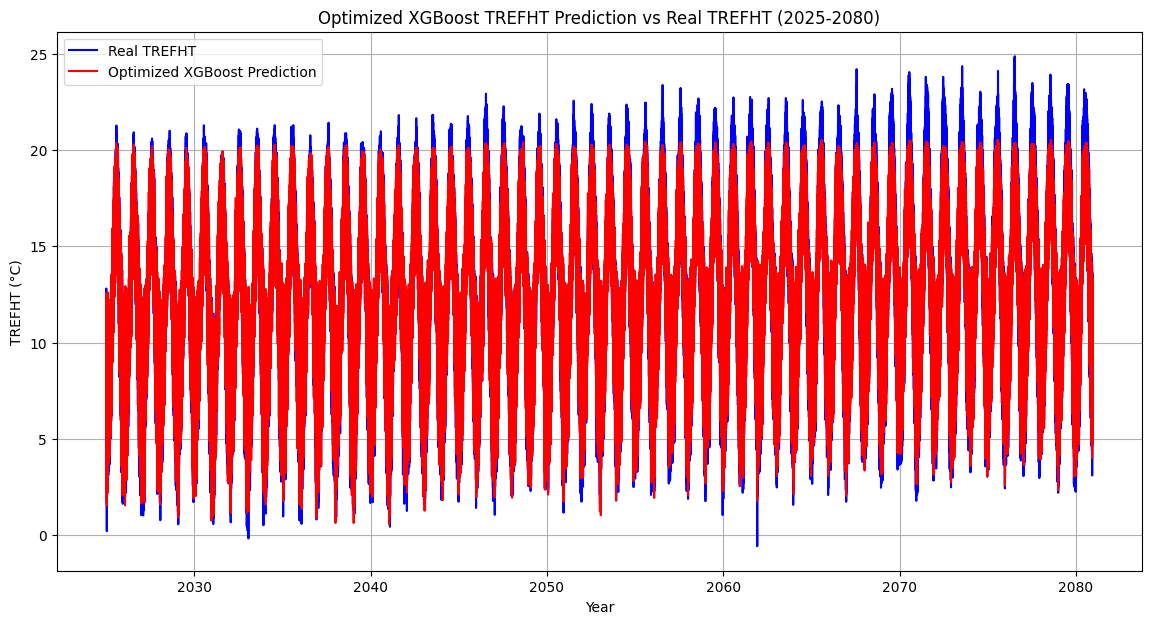

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Assume that y_test and y_pred_optimized are already available as the model's prediction results and true values

# Calculate MAE (mean absolute error) and RMSE (root mean square error)
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))

# Output MAE and RMSE
print(f"✅ Optimized MAE: {mae_optimized:.2f} °C")
print(f"✅ Optimized RMSE: {rmse_optimized:.2f} °C")

# Draw a comparison chart of the predicted results and the true values
plt.figure(figsize=(14, 7))
plt.plot(test_df['time'], y_test, label='Real TREFHT', color='blue')  # Real value
plt.plot(test_df['time'], y_pred_optimized, label='Optimized XGBoost Prediction', color='red')  # Prediction value
plt.title('Optimized XGBoost TREFHT Prediction vs Real TREFHT (2025-2080)')
plt.xlabel('Year')
plt.ylabel('TREFHT (°C)')
plt.legend()
plt.grid(True)
plt.show()


# Thermal map of predicted temperature in the geographical area on January 1, 2025

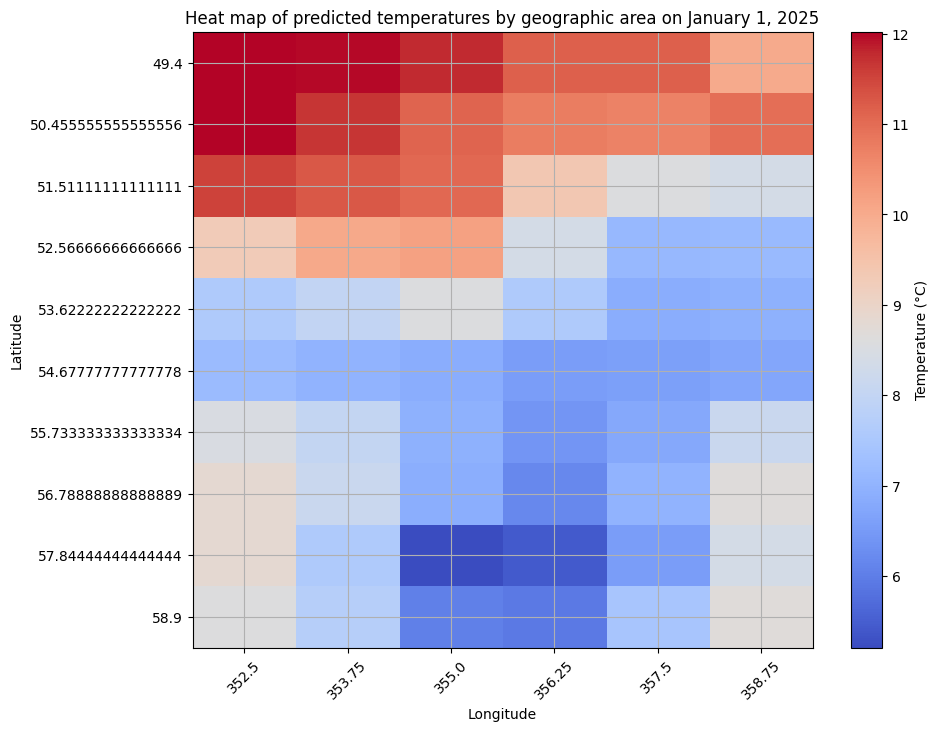

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you already have pred_data_reshaped (time, latitude, longitude)

# Get the prediction result for a specific time point
time_index = 0  # Select the first time point as an example
pred_at_time = pred_data_reshaped[time_index, :, :] # All longitude and latitude prediction data at this time point

# Draw a heat map at this time point
plt.figure(figsize=(10, 8))
plt.imshow(pred_at_time, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.title(f"Heat map of predicted temperatures by geographic area on January 1, 2025")
plt.colorbar(label='Temperature (°C)')  # 色标表示温度
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xticks(np.arange(len(lon)), lon, rotation=45)
plt.yticks(np.arange(len(lat)), lat)
plt.grid(True)
plt.show()


Each pixel in the heat map represents the predicted temperature at that latitude and longitude point, and the entire heat map shows the predicted temperature of all latitude and longitude points in the range of 49.4 to 58.9 latitude and 352.5 to 358.75 longitude on January 1, 2025.